# Wave data exploration with JupySQL

Basic analysis of the synthetic tokamak diagnostic dataset from the
DuckLake POC, mixing SQL (via [JupySQL](https://jupysql.ploomber.io/))
and Python in the same notebook: SQL for the heavy lifting over the
Parquet files (aggregation, even a trapezoidal-integration window
function), Python/matplotlib for plotting and cross-checking.

This notebook is self-contained -- it regenerates the same dataset used
in `src/ducklake_poc/local_demo.py` (several diagnostic groups: rogowski,
flux_loops, diamagnetic_loop, thomson, and mirnov) and reads the
compacted Parquet files directly with DuckDB, so it doesn't need
Postgres, nginx, or a DuckLake catalog attach to run.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from ducklake_poc import local_demo

## 1. Generate the dataset

Reuses the exact same generation + compaction code as `local_demo.py`:
several small diagnostic groups plus `mirnov/probe_01`, forced to
2,000,000 samples -- standing in for the real physical reason Mirnov
coils (high-frequency MHD pickup coils) are the diagnostic most likely to
produce a genuinely huge wave, compacted with wave- and
stage-boundary-aware row groups (see the main README for why that
matters).

In [2]:
local_demo.generate_raw_files()
compacted_paths = local_demo.compact_locally()
compacted_paths

generated 18 raw wave files across 5 diagnostic groups (including mirnov/probe_01 with 2,000,000 samples across data_versions ['a1b2c3d', 'e4f5a6b']) in /tmp/ducklake_local_demo_raw


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

compacted into 9 file(s), 29.9MB total:
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/diamagnetic_loop__diamagnetic_loop_main__02e1926__6f07be85.parquet  (0.0MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/flux_loops__multi__65b5046__130a2523.parquet  (0.1MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__a1b2c3d__cf01a93d.parquet  (8.5MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__a1b2c3d__c74f25a5.parquet  (6.2MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__e4f5a6b__9fd253d7.parquet  (8.5MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__e4f5a6b__077447e2.parquet  (6.2MB)
    /home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__multi__a658d00__4540400e.parquet  (0.5MB)
    /home/claude/ducklake-poc/data/lake/local_demo

['/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/diamagnetic_loop__diamagnetic_loop_main__02e1926__6f07be85.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/flux_loops__multi__65b5046__130a2523.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__a1b2c3d__cf01a93d.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__a1b2c3d__c74f25a5.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__e4f5a6b__9fd253d7.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__mirnov_probe_01__e4f5a6b__077447e2.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/mirnov__multi__a658d00__4540400e.parquet',
 '/home/claude/ducklake-poc/data/lake/local_demo/campaign-2026a/999/rogowski__multi__b44edf3__0d0cb829.parquet',
 '/home/claude/ducklake-poc/data/lake/lo

## 2. Connect JupySQL to DuckDB

`%sql` / `%%sql` run against an in-memory DuckDB connection. We point a
view at the compacted Parquet files with `read_parquet`, so ordinary SQL
below is scanning the actual compacted output -- the same files
`fetch_wave.py` reads over HTTP elsewhere in this repo.

In [3]:
%load_ext sql
%config SqlMagic.autopandas = True
%config SqlMagic.displaycon = False
%sql duckdb:///:memory:

Connecting to 'duckdb:///:memory:'

In [4]:
glob_pattern = str(local_demo.LAKE_DIR / "**" / "*.parquet")

# Built dynamically (glob_pattern is a Python variable), so invoke the
# magic programmatically with an f-string rather than JupySQL's
# named-parameter binding, which is meant for literal values in WHERE
# clauses, not for splicing a path into a table function call.
get_ipython().run_line_magic(
    "sql", f"CREATE OR REPLACE VIEW waves AS SELECT * FROM read_parquet('{glob_pattern}')"
)

,Success


## 3. Basic shape of the data

In [5]:
%%sql
SELECT
    count(*)                     AS total_samples,
    count(DISTINCT experiment)   AS total_experiments,
    count(DISTINCT stage)        AS total_stages,
    count(DISTINCT wave)         AS total_waves,
    count(DISTINCT data_version) AS distinct_data_versions,
    min(x)                       AS x_min,
    max(x)                       AS x_max
FROM waves

,total_samples,total_experiments,total_stages,total_waves,distinct_data_versions,x_min,x_max
0,4081000,1,5,17,7,0.0,500.0


### Data versions (recalibration reruns)

`data_version` models a real operational pattern: scientists periodically
revise a diagnostic's calibration and rerun the pipeline, producing a new,
independent copy of every channel in that diagnostic group -- old
versions are kept, not overwritten. Most (shot, stage) combinations only
get processed once; a few have 2 or 3 versions here.

In [6]:
version_counts = %sql SELECT stage, data_version, count(*) AS n_samples, count(DISTINCT wave) AS n_channels FROM waves GROUP BY stage, data_version ORDER BY stage, data_version
version_counts

,stage,data_version,n_samples,n_channels
0,diamagnetic_loop,02e1926,3000,1
1,flux_loops,65b5046,10000,2
2,mirnov,a1b2c3d,2000000,1
3,mirnov,a658d00,56000,7
4,mirnov,e4f5a6b,2000000,1
5,rogowski,b44edf3,10000,2
6,thomson,54c5297,2000,4


### Samples and channels per diagnostic group

`stage` and `wave` are both dictionary-encoded columns (see
`parquet_encoding.py`) -- `stage` is the diagnostic group (a handful of
distinct values), `wave` is the specific channel it produced. This counts
across all data_versions combined, so a channel with 2 versions
contributes twice.

In [7]:
stage_counts = %sql SELECT stage, count(*) AS n_samples, count(DISTINCT wave) AS n_channels FROM waves GROUP BY stage ORDER BY stage
stage_counts

,stage,n_samples,n_channels
0,diamagnetic_loop,3000,1
1,flux_loops,10000,2
2,mirnov,4056000,8
3,rogowski,10000,2
4,thomson,2000,4


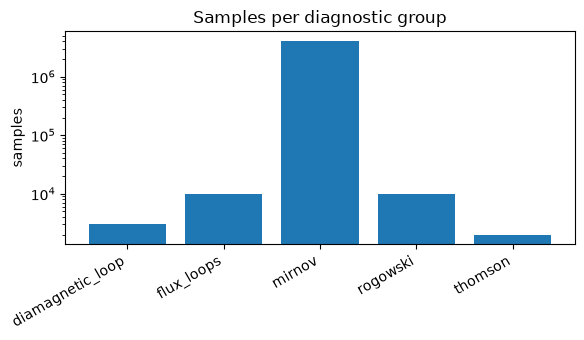

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(stage_counts["stage"], stage_counts["n_samples"])
ax.set_ylabel("samples")
ax.set_title("Samples per diagnostic group")
ax.set_yscale("log")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Plot a small wave

Pull one Thomson scattering channel's samples straight into a DataFrame
with `%sql` and plot it -- Thomson is a pulsed spatial profile
measurement, so it's one of the smallest channels in the dataset (a few
hundred points), unlike the high-frequency Mirnov coils used below.
`data_version` is a git-commit-hash-style id (not a sequential number),
drawn randomly for this stage, so we look it up rather than hardcode a
literal -- pinning it explicitly matters regardless: without it, a
channel with multiple recalibration reruns would mix independent copies
of the same signal together.

In [9]:
thomson_version = %sql SELECT min(data_version) AS v FROM waves WHERE stage = 'thomson'
thomson_version = thomson_version["v"].iloc[0]
print(f"using thomson data_version: {thomson_version}")

using thomson data_version: 54c5297


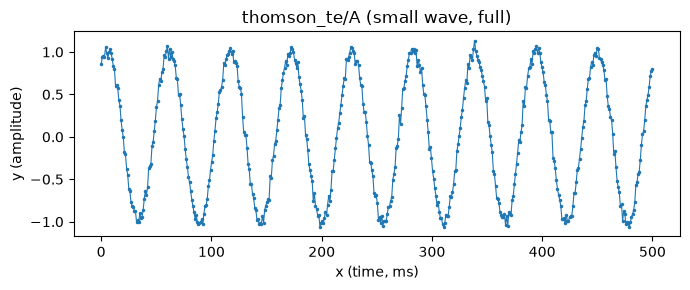

In [10]:
wave0 = get_ipython().run_line_magic(
    "sql",
    f"SELECT x, y FROM waves WHERE stage = 'thomson' AND wave = 'thomson_te/A' "
    f"AND data_version = '{thomson_version}' ORDER BY x",
)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(wave0["x"], wave0["y"], linewidth=0.8, marker=".", markersize=3)
ax.set_xlabel("x (time, ms)")
ax.set_ylabel("y (amplitude)")
ax.set_title("thomson_te/A (small wave, full)")
plt.tight_layout()
plt.show()

## 5. Area under the curve, computed in SQL

Trapezoidal integration via a window function (`lead` to pair each sample
with its successor), computed for every Thomson channel in one query --
this is the kind of aggregate that's cheap to push into SQL/DuckDB rather
than pulling every wave into Python first.

In [11]:
get_ipython().run_cell_magic(
    "sql",
    "auc_by_wave <<",
    f"""
WITH ordered AS (
    SELECT
        wave, x, y,
        lead(x) OVER (PARTITION BY wave ORDER BY x) AS x_next,
        lead(y) OVER (PARTITION BY wave ORDER BY x) AS y_next
    FROM waves
    WHERE stage = 'thomson' AND data_version = '{thomson_version}'  -- pin one version:
                                                                      -- mixing versions in
                                                                      -- the same window
                                                                      -- partition would pair
                                                                      -- up unrelated samples
)
SELECT
    wave,
    sum(0.5 * (y + y_next) * (x_next - x)) AS auc_sql
FROM ordered
WHERE x_next IS NOT NULL
GROUP BY wave
ORDER BY wave
""",
)

In [12]:
auc_df = auc_by_wave
auc_df

,wave,auc_sql
0,thomson_ne/A,8.131622
1,thomson_ne/B,17.163954
2,thomson_te/A,5.127067
3,thomson_te/B,12.010099


### Cross-check against `numpy.trapezoid`

Same trapezoidal rule, computed in plain Python on the same data, to make
sure the SQL version is actually correct and not just plausible-looking.

In [13]:
check = get_ipython().run_line_magic(
    "sql",
    f"SELECT x, y FROM waves WHERE wave = 'thomson_te/A' AND data_version = '{thomson_version}' ORDER BY x",
)
np_auc = np.trapezoid(check["y"].to_numpy(), check["x"].to_numpy())
sql_auc = auc_df.loc[auc_df["wave"] == "thomson_te/A", "auc_sql"].iloc[0]

print(f"numpy.trapezoid : {np_auc:.10f}")
print(f"SQL (window fn) : {sql_auc:.10f}")
print(f"match           : {np.isclose(np_auc, sql_auc)}")

numpy.trapezoid : 5.1270671706
SQL (window fn) : 5.1270671706
match           : True


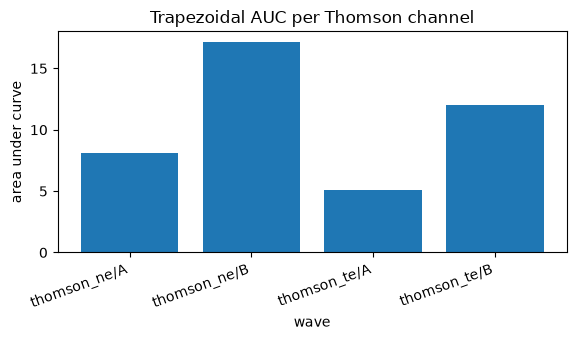

In [14]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(auc_df["wave"], auc_df["auc_sql"])
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("wave")
ax.set_ylabel("area under curve")
ax.set_title("Trapezoidal AUC per Thomson channel")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 6. Zooming into the big wave

`mirnov/probe_01` has 2,000,000 samples over the shot's 500ms duration
(a 4MHz digitization rate) -- Mirnov coils digitize high-frequency
(kHz-MHz) magnetic fluctuations, so they're the diagnostic group
realistically capable of producing a wave this size. This channel has
two data_versions in this dataset (a recalibration rerun) -- pinned here
to the deterministic id `local_demo.py` forces this channel to
(`BIG_WAVE_VERSIONS[0]`) -- filtering by `x` (now genuine milliseconds,
not a normalized fraction) lets DuckDB's own row-group pruning do its
job, and pinning `data_version` keeps the two independent copies from
being scanned together. This is the same mechanism `fetch_wave.py`
exploits over HTTP, just observed here directly through SQL against the
local files. This is a literal 1ms slice, no unit workaround needed.

In [15]:
%%sql window_slice <<
SELECT x, y FROM waves
WHERE wave = 'mirnov/probe_01' AND data_version = 'a1b2c3d' AND x BETWEEN 250.0 AND 251.0
ORDER BY x

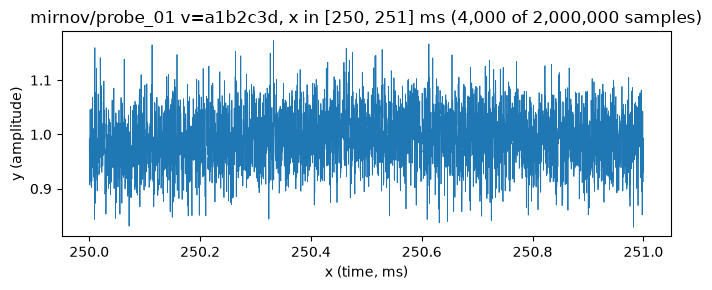

In [16]:
slice_df = window_slice

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(slice_df["x"], slice_df["y"], linewidth=0.6)
ax.set_xlabel("x (time, ms)")
ax.set_ylabel("y (amplitude)")
ax.set_title(f"mirnov/probe_01 v=a1b2c3d, x in [250, 251] ms ({len(slice_df):,} of 2,000,000 samples)")
plt.tight_layout()
plt.show()

### How much of the wave did that actually touch?

Using `parquet_metadata()` directly against the compacted files -- the
same row-group statistics `manifest.py` extracts to build `wave_manifest`
in Postgres, queried here without any external service. `data_version` is
included because it's a hard partition boundary in `compact.py` (like
`stage`, enforced at both the row-group AND file level): a row group (or
file) never mixes two different calibration reruns.

In [17]:
import glob as globmod

files = sorted(globmod.glob(glob_pattern, recursive=True))
union_sql = " UNION ALL ".join(f"SELECT * FROM parquet_metadata('{f}')" for f in files)

# Built dynamically, so invoke the magic programmatically rather than via
# static %%sql cell text (JupySQL's `%sql` doesn't do brace-interpolation
# of arbitrary Python expressions inside the query body).
get_ipython().run_line_magic("sql", f"CREATE OR REPLACE VIEW rg_meta AS {union_sql}")

,Success


In [18]:
rg_stats = %sql SELECT row_group_id, file_name,        min(CASE WHEN path_in_schema='wave' THEN CAST(stats_min_value AS VARCHAR) END) AS wave_min,        max(CASE WHEN path_in_schema='wave' THEN CAST(stats_max_value AS VARCHAR) END) AS wave_max,        min(CASE WHEN path_in_schema='data_version' THEN CAST(stats_min_value AS VARCHAR) END) AS data_version,        min(CASE WHEN path_in_schema='x' THEN CAST(stats_min_value AS DOUBLE) END) AS x_min,        max(CASE WHEN path_in_schema='x' THEN CAST(stats_max_value AS DOUBLE) END) AS x_max FROM rg_meta GROUP BY row_group_id, file_name

target_wave = "mirnov/probe_01"
wave_groups = rg_stats[(rg_stats.wave_min <= target_wave) & (rg_stats.wave_max >= target_wave) & (rg_stats.data_version == "a1b2c3d")]
touched = wave_groups[(wave_groups.x_max >= 250.0) & (wave_groups.x_min <= 251.0)]

print(f"total row groups belonging to {target_wave} v1 : {len(wave_groups)}")
print(f"row groups touched by the 1ms x-window query    : {len(touched)}")
print(f"fraction touched                                : {len(touched) / len(wave_groups):.2%}")

total row groups belonging to mirnov/probe_01 v1 : 100
row groups touched by the 1ms x-window query    : 1
fraction touched                                : 1.00%


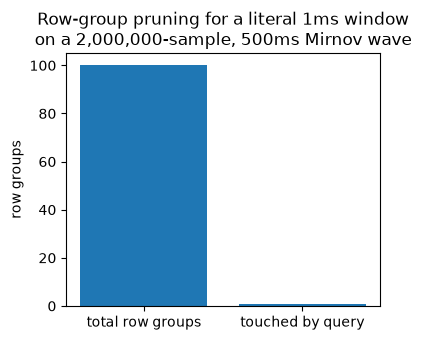

In [19]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.bar(["total row groups", "touched by query"], [len(wave_groups), len(touched)])
ax.set_ylabel("row groups")
ax.set_title("Row-group pruning for a literal 1ms window\non a 2,000,000-sample, 500ms Mirnov wave")
plt.tight_layout()
plt.show()

## Wrap-up

- SQL (via JupySQL) handled the aggregation, the window-function AUC
  integration, and the row-group pruning query -- all pushed down into
  DuckDB rather than pulled into Python row by row.
- Python/matplotlib handled visualization and the `numpy.trapezoid`
  cross-check.
- The same `x`-based row-group pruning that made the narrow-window query
  above touch a single row group instead of scanning the whole channel is
  what `fetch_wave.py` relies on to serve a 1ms slice of a
  multi-million-sample Mirnov wave over plain HTTP without DuckDB in the
  loop at all -- see the main README.